Step 1: Loading hospital closure data...
Original closure data shape: (198, 15)
Original zip code examples: [4901.0, 35650.0, 75862.0, 73075.0, 51245.0, 36784.0, 43526.0, 49953.0, 37762.0, 78945.0]
Dropped 2 rows with invalid zip codes
Standardized zip code examples: ['04901', '35650', '75862', '73075', '51245', '36784', '43526', '49953', '37762', '78945']
Zip codes with multiple closures: 3
Sample zip codes with multiple closures: {'24701': 2, '36784': 2, '78945': 2}
Excluding zip codes with multiple closures to ensure clean treatment definition...
Remaining closures after excluding multiple-closure zip codes: 190
Final closure data shape: (190, 18)
Unique zip codes in closure data: 190

Step 2: Loading local Zillow ZHVI data and converting to quarterly...
Original ZHVI data shape: (26316, 313)
Original RegionName examples: [77494, 8701, 77449, 11368, 77084, 79936, 11385, 78660, 11208, 90011]
Dropped 1933843 rows with missing data
Converting to quarterly averages...
After quarterly ag

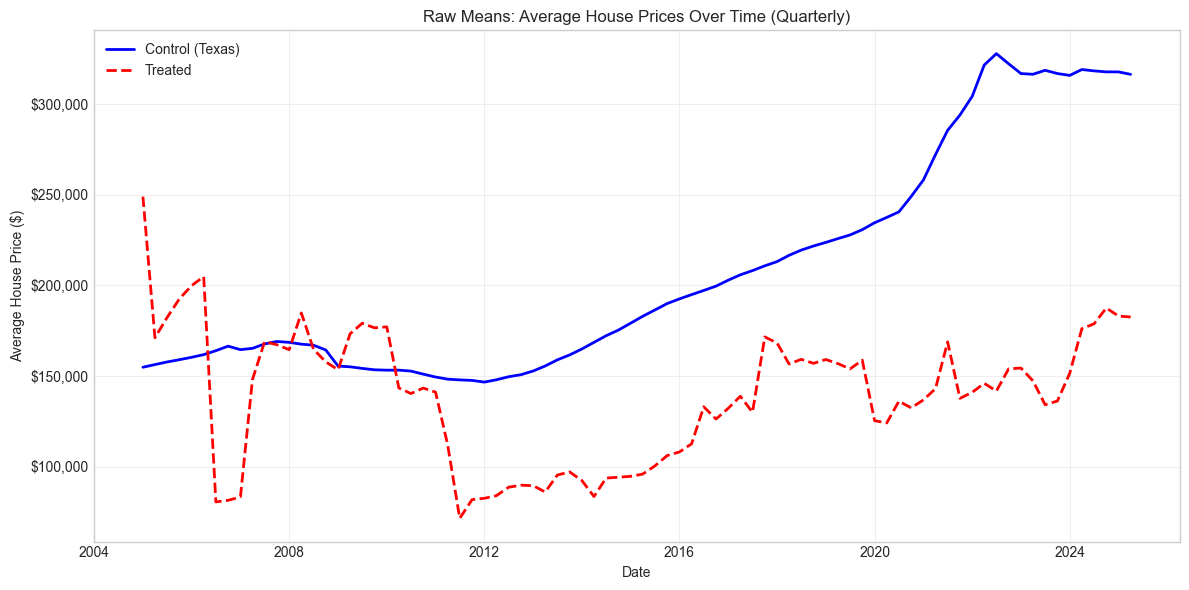

Saved event study plot to event_study_coefficients.png


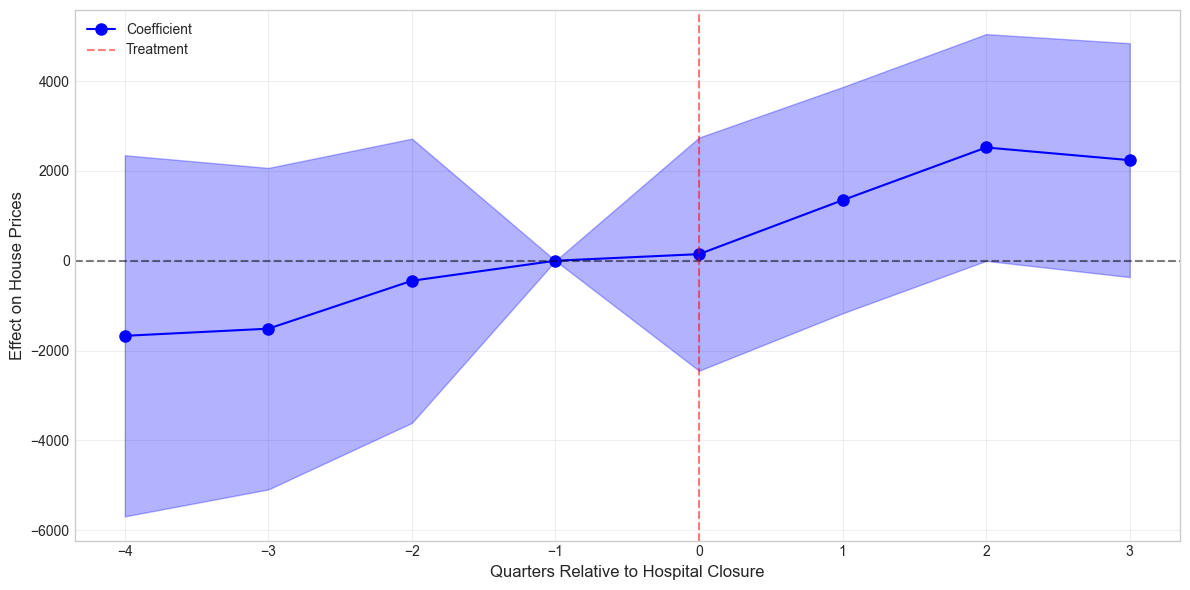


Step 6: Saving summary statistics...
Saved enhanced summary statistics (with detailed closure date distribution) to summary_statistics.tex

=== SUMMARY STATISTICS ===
Total observations: 93,719
Unique zip codes: 1,250
Treated zip codes: 51
Control zip codes (Texas only): 1199
Time period: 2000-01-01 00:00:00 to 2025-04-01 00:00:00
Hospital closures: 190

Treatment Statistics:
Pre-treatment observations: 218
Post-treatment observations: 228
Closure dates range: 2005-03-01 00:00:00 to 2025-05-01 00:00:00

ZHVI Statistics:
Mean ZHVI: $205,089
Median ZHVI: $169,202
Min ZHVI: $32,464
Max ZHVI: $2,088,515

Balance Check:
Mean ZHVI in treated areas: $136,960
Mean ZHVI in control areas (Texas): $205,414
Difference: $-68,454


In [15]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf
from linearmodels import PanelOLS
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import re

# Helper function for consistent zip code formatting
def standardize_zip_code(zip_col):
    """
    Standardize zip codes to 5-digit zero-padded strings
    """
    # Convert to string and handle various formats
    zip_series = round(zip_col,0)
    zip_series = zip_series.astype('Int64')  # Use nullable integer
    
    zip_series = zip_series.astype(str)
    zip_series = zip_series.str.replace(r'[^0-9]', '', regex=True)
    
    # Remove any values that are clearly not zip codes
    zip_series = zip_series.replace(['', 'nan', 'None', '0'], np.nan)
    zip_series = pd.to_numeric(zip_series, errors='coerce')
    zip_series = zip_series.astype('Int64')  # Use nullable integer
    zip_series = zip_series.astype(str).str.replace('<NA>', '')
    # Remove any non-numeric characters (spaces, dashes, etc.)
   

    # Zero-pad to 5 digits for valid zip codes
    mask = zip_series.str.len() > 0
   
    zip_series.loc[mask] = zip_series.loc[mask].astype(int).astype(str).str.zfill(5)
    
    # Replace empty strings with NaN
    zip_series = zip_series.replace('', np.nan)
    
    return zip_series

# Step 1: Load and prepare hospital closure data
def prepare_closure_data(closure_file):
    """
    Prepare hospital closure data for DiD analysis
    """
    # Read hospital closures
    closures = pd.read_excel(closure_file)
    
    print(f"Original closure data shape: {closures.shape}")
    print(f"Original zip code examples: {closures['Zip'].head(10).tolist()}")
    
    # Standardize zip codes
    closures['zip'] = standardize_zip_code(closures['Zip'])
    
    # Remove rows with invalid zip codes
    before_drop = len(closures)
    closures = closures.dropna(subset=['zip'])
    after_drop = len(closures)
    print(f"Dropped {before_drop - after_drop} rows with invalid zip codes")
    print(f"Standardized zip code examples: {closures['zip'].head(10).tolist()}")
    
    # Create treatment timing variable
    closures['closure_date'] = pd.to_datetime(
        closures['Closure Year'].fillna(0).astype(int).astype(str) + '-' + 
        closures['Closure Month'].str.strip(), 
        format='%Y-%B',
        errors='coerce'  # This will convert invalid dates to NaT
    )
    
    # Check for multiple closures per zip code
    closure_counts = closures['zip'].value_counts()
    multiple_closures = closure_counts[closure_counts > 1]
    
    print(f"Zip codes with multiple closures: {len(multiple_closures)}")
    if len(multiple_closures) > 0:
        print(f"Sample zip codes with multiple closures: {multiple_closures.head().to_dict()}")
        
        # Exclude zip codes with multiple closures for clean treatment definition
        print("Excluding zip codes with multiple closures to ensure clean treatment definition...")
        closures = closures[~closures['zip'].isin(multiple_closures.index)]
        print(f"Remaining closures after excluding multiple-closure zip codes: {len(closures)}")
    
    # Create closure type dummy
    closures['complete_closure'] = (closures['Closure'] == 0).astype(int)
    
    print(f"Final closure data shape: {closures.shape}")
    print(f"Unique zip codes in closure data: {closures['zip'].nunique()}")
    
    return closures

# Step 2: Load and prepare local Zillow ZHVI data (MODIFIED FOR QUARTERLY)
def get_zillow_data(zhvi_file="Zip_zhvi_uc_sfrcondo_tier_0.33_0.67_sm_sa_month.csv"):
    """
    Load Zillow ZHVI data from local CSV file and convert to quarterly
    """
    # Read data
    zhvi = pd.read_csv(zhvi_file)
    
    print(f"Original ZHVI data shape: {zhvi.shape}")
    print(f"Original RegionName examples: {zhvi['RegionName'].head(10).tolist()}")
    
    # Define ID variables based on the column structure provided
    id_vars = ['RegionID', 'SizeRank', 'RegionName', 'RegionType', 'StateName', 
               'State', 'City', 'Metro', 'CountyName']
    
    # Get date columns (all columns that are not in id_vars)
    date_cols = [col for col in zhvi.columns if col not in id_vars]
    
    # Reshape from wide to long format
    zhvi_long = pd.melt(
        zhvi,
        id_vars=id_vars,
        value_vars=date_cols,
        var_name='date',
        value_name='zhvi'
    )
    
    # Convert date to datetime - handle the M/D/YY format
    zhvi_long['date'] = pd.to_datetime(zhvi_long['date'], errors='coerce')
    
    # Standardize zip codes from RegionName
    zhvi_long['zip'] = standardize_zip_code(zhvi_long['RegionName'])
    
    # Remove rows with invalid zip codes or ZHVI values or dates
    before_clean = len(zhvi_long)
    zhvi_long = zhvi_long.dropna(subset=['zhvi', 'zip', 'date'])
    after_clean = len(zhvi_long)
    print(f"Dropped {before_clean - after_clean} rows with missing data")
    
    # CONVERT TO QUARTERLY AVERAGES
    print("Converting to quarterly averages...")
    zhvi_long['quarter'] = zhvi_long['date'].dt.to_period('Q')
    
    # Group by zip code, quarter, and other identifying variables
    quarterly_groups = ['zip', 'quarter', 'RegionID', 'StateName', 'State', 'City', 'Metro', 'CountyName']
    zhvi_quarterly = zhvi_long.groupby(quarterly_groups).agg({
        'zhvi': 'mean'
    }).reset_index()
    
    # Convert quarter back to datetime (use first day of quarter)
    zhvi_quarterly['date'] = zhvi_quarterly['quarter'].dt.to_timestamp()
    
    print(f"After quarterly aggregation: {len(zhvi_quarterly):,} observations")
    print(f"Loaded {len(zhvi_quarterly):,} quarterly observations from {zhvi_quarterly['zip'].nunique():,} zip codes")
    print(f"Date range: {zhvi_quarterly['date'].min()} to {zhvi_quarterly['date'].max()}")
    
    return zhvi_quarterly

# Step 3: Create panel dataset for DiD (MODIFIED FOR TEXAS CONTROLS AND QUARTERLY)
def create_did_panel(closures, zhvi_data, buffer_quarters=4):
    """
    Create panel dataset for staggered DiD analysis
    Modified to use only Texas zip codes as controls and quarterly data
    
    Parameters:
    - closures: hospital closure data
    - zhvi_data: Zillow home value data (quarterly)
    - buffer_quarters: quarters before/after to include (default: 4 = 1 year)
    """
    
    # Only complete closures count as treatment
    complete_closures = closures[closures['complete_closure'] == 1].copy()
    partial_closures = closures[closures['complete_closure'] == 0].copy()
    
    print(f"Complete closures (treatment): {len(complete_closures)}")
    print(f"Partial closures (control): {len(partial_closures)}")
    
    # Get treated zip codes (only complete closures)
    treated_zips = set(complete_closures['zip'].unique())
    print(f"Number of treated zip codes (complete closures only): {len(treated_zips)}")
    print(f"Sample treated zip codes: {list(treated_zips)[:10]}")
    
    # Get all zip codes in ZHVI data
    all_zhvi_zips = set(zhvi_data['zip'].unique())
    print(f"Number of zip codes in ZHVI data: {len(all_zhvi_zips)}")
    
    # MODIFIED: Get Texas zip codes for control group
    texas_data = zhvi_data[zhvi_data['StateName'] == 'TX']
    texas_zips = set(texas_data['zip'].unique())
    print(f"Number of Texas zip codes in ZHVI data: {len(texas_zips)}")
    
    # Check overlap
    overlap = treated_zips.intersection(all_zhvi_zips)
    print(f"Overlap between treated and ZHVI zip codes: {len(overlap)}")
    
    # MODIFIED: Control group is Texas zip codes that never had any closure
    # Exclude any Texas zip codes that had closures
    control_zips = texas_zips - set(closures['zip'].unique())
    
    print(f"Texas zip codes with no closures (control group): {len(control_zips)}")
    
    # MODIFIED: Filter data to include only treated zip codes and Texas controls
    valid_zips = treated_zips.union(control_zips)
    panel_data = zhvi_data[zhvi_data['zip'].isin(valid_zips)].copy()
    
    print(f"Panel data size after filtering to treated + Texas controls: {len(panel_data):,} observations")
    
    # Log transform outcome (handle zeros/negatives) - do this early
    panel_data = panel_data[panel_data['zhvi'] > 0]  # Remove non-positive values
    #panel_data['zh'] = panel_data['zhvi']
    print(f"After removing non-positive ZHVI values: {len(panel_data):,} observations")
    
    # Merge closure information - only for complete closures
    merge_cols = ['zip', 'closure_date', 'complete_closure']
    if '# of Beds' in complete_closures.columns:
        merge_cols.append('# of Beds')
    
    panel_data = panel_data.merge(
        complete_closures[merge_cols],
        on='zip',
        how='left'
    )
    
    print(f"Panel data size after merge: {len(panel_data):,} observations")
    
    # Create treatment indicators (only complete closures are treated)
    panel_data['treated'] = panel_data['zip'].isin(treated_zips).astype(int)
    
    # Initialize post-treatment indicator 
    panel_data['post'] = 0
    
    print(f"Treated zip codes in panel: {panel_data[panel_data['treated']==1]['zip'].nunique()}")
    print(f"Control zip codes in panel (Texas only): {panel_data[panel_data['treated']==0]['zip'].nunique()}")
    
    # For treated units, set post=1 after closure
    treated_mask = panel_data['treated'] == 1
    panel_data.loc[treated_mask, 'post'] = (
        panel_data.loc[treated_mask, 'date'] >= panel_data.loc[treated_mask, 'closure_date']
    ).astype(int)
    
    # Create relative time variable (in quarters) - only for treated units
    panel_data['rel_time'] = np.nan
    panel_data.loc[treated_mask, 'rel_time'] = (
        (panel_data.loc[treated_mask, 'date'] - panel_data.loc[treated_mask, 'closure_date']).dt.days / 91.25
    ).round()
    
    print(f"Panel data before buffer filtering: {len(panel_data):,} observations")
    print(f"Treated observations before buffer: {panel_data['treated'].sum():,}")
    print(f"Post-treatment observations before buffer: {panel_data['post'].sum():,}")
    
    # Filter to buffer window around treatment for treated units ONLY
    if buffer_quarters is not None:
        # Keep all control observations
        control_mask = panel_data['treated'] == 0
        
        # For treated observations, keep only those within buffer window
        treated_in_window = (
            (panel_data['treated'] == 1) & 
            (panel_data['rel_time'] >= -buffer_quarters) & 
            (panel_data['rel_time'] <= buffer_quarters)
        )
        
        # Combine: all controls + treated within window
        keep_mask = control_mask | treated_in_window
        panel_data = panel_data[keep_mask].copy()
        
        print(f"After applying {buffer_quarters}-quarter buffer: {len(panel_data):,} observations")
        print(f"Treated observations after buffer: {panel_data['treated'].sum():,}")
        print(f"Control observations after buffer: {(panel_data['treated']==0).sum():,}")
    
    print(f"Final panel data size: {len(panel_data):,} observations")
    print(f"Treated observations: {panel_data['treated'].sum():,}")
    print(f"Post-treatment observations: {panel_data['post'].sum():,}")
    print(f"Unique treated zip codes: {panel_data[panel_data['treated']==1]['zip'].nunique()}")
    print(f"Unique control zip codes: {panel_data[panel_data['treated']==0]['zip'].nunique()}")
    
    # Check for missing values in key variables
    print(f"Missing values in zhvi: {panel_data['zhvi'].isna().sum()}")
    print(f"Missing values in treated: {panel_data['treated'].isna().sum()}")
    print(f"Missing values in post: {panel_data['post'].isna().sum()}")
    print(f"Missing values in zip: {panel_data['zip'].isna().sum()}")
    print(f"Missing values in date: {panel_data['date'].isna().sum()}")
    
    return panel_data

# Step 4: Implement staggered DiD estimator (EVENT STUDY ONLY)
def estimate_staggered_did(panel_data):
    """
    Estimate staggered DiD using event study specification only
    """
    results = {}
    
    # Event Study Specification - only for treated units with valid rel_time
    print("Estimating event study model...")
    try:
        # For event study, we need treated units with valid rel_time
        event_data = panel_data[
            (panel_data['treated'] == 1) & 
            (panel_data['rel_time'].notna())
        ].copy()
        
        print(f"Event study data: {len(event_data)} treated observations")
        
        if len(event_data) > 0:
            # Create event time dummies (exclude -1 as reference)
            event_times = range(-4, 4)  # -4 to +4 quarters
            for t in event_times:
                if t != -1:  # Omit period -1 as reference
                    # Use "neg" for negative times to avoid minus signs in variable names
                    if t < 0:
                        var_name = f'event_qneg{abs(t)}'
                    else:
                        var_name = f'event_q{t}'
                    event_data[var_name] = (event_data['rel_time'] == t).astype(int)
            
            # Only include event time dummies that have variation
            event_vars = []
            for t in event_times:
                if t != -1:
                    if t < 0:
                        var_name = f'event_qneg{abs(t)}'
                    else:
                        var_name = f'event_q{t}'
                    if var_name in event_data.columns and event_data[var_name].sum() > 0:
                        event_vars.append(var_name)
            
            print(f"Event variables with variation: {len(event_vars)}")
            
            if event_vars:
                # Prepare event study data
                event_regression_vars = ['zhvi', 'zip', 'date'] + event_vars
                event_regression_data = event_data[event_regression_vars].dropna()
                
                formula_event = f'zhvi ~ {" + ".join(event_vars)} + C(zip) + C(date)'
                model_event = smf.ols(formula_event, data=event_regression_data)
                results['event_study'] = model_event.fit()
                print(f"Event study model estimated with {len(event_regression_data)} observations")
                
                # Save event study results to tex file
                save_regression_table(results['event_study'], 'event_study_results.tex',
                                    title='Event Study Results: Hospital Closure Effects on House Prices',
                                    label='tab:event_study',
                                    event_vars=event_vars)
            else:
                print("Warning: No event time dummies with variation found")
                results['event_study'] = None
        else:
            print("Warning: No treated observations with valid rel_time for event study")
            results['event_study'] = None
            
    except Exception as e:
        print(f"Error in event study estimation: {e}")
        results['event_study'] = None
    
    return results, panel_data

# Save regression results as LaTeX tables
def save_regression_table(model, filename, title='', label='', event_vars=None):
    """
    Save regression results in publication-ready LaTeX format
    """
    # Get summary
    summary = model.summary()
    
    # Start building LaTeX table
    tex_content = "\\begin{table}[htbp]\n"
    tex_content += "\\centering\n"
    if title:
        tex_content += f"\\caption{{{title}}}\n"
    if label:
        tex_content += f"\\label{{{label}}}\n"
    
    # For publication format, we'll extract key coefficients
    tex_content += "\\begin{tabular}{lcccc}\n"
    tex_content += "\\hline\\hline\n"
    tex_content += "Variable & Coefficient & Std. Error & t-statistic & P-value \\\\\n"
    tex_content += "\\hline\n"
    
    # Extract key coefficients (not fixed effects)
    params = model.params
    std_errors = model.bse
    tvalues = model.tvalues
    pvalues = model.pvalues
    
    # For event study, include all event time coefficients
    if event_vars:
        for var in event_vars:
            if var in params.index:
                coef = params[var]
                se = std_errors[var]
                t = tvalues[var]
                p = pvalues[var]
                
                # Format p-value with stars
                stars = ''
                if p < 0.01:
                    stars = '***'
                elif p < 0.05:
                    stars = '**'
                elif p < 0.1:
                    stars = '*'
                
                # Extract time period from variable name
                if 'neg' in var:
                    time = f"$q = -{var.split('neg')[1]}$"
                else:
                    time = f"$q = +{var.split('q')[1]}$"
                
                tex_content += f"{time} & {coef:.4f}{stars} & ({se:.4f}) & {t:.2f} & {p:.3f} \\\\\n"
    
    tex_content += "\\hline\n"
    
    # Add model statistics
    tex_content += f"Observations & \\multicolumn{{4}}{{c}}{{{model.nobs:.0f}}} \\\\\n"
    tex_content += f"R-squared & \\multicolumn{{4}}{{c}}{{{model.rsquared:.3f}}} \\\\\n"
    tex_content += f"Adj. R-squared & \\multicolumn{{4}}{{c}}{{{model.rsquared_adj:.3f}}} \\\\\n"
    
    # Note about fixed effects
    tex_content += "Zip Code FE & \\multicolumn{4}{c}{Yes} \\\\\n"
    tex_content += "Quarter FE & \\multicolumn{4}{c}{Yes} \\\\\n"
    
    tex_content += "\\hline\\hline\n"
    tex_content += "\\end{tabular}\n"
    tex_content += "\\begin{tablenotes}\n"
    tex_content += "\\small\n"
    tex_content += "\\item Note: Standard errors in parentheses. * p$<$0.10, ** p$<$0.05, *** p$<$0.01. Event time is measured in quarters relative to hospital closure.\n"
    tex_content += "\\end{tablenotes}\n"
    tex_content += "\\end{table}\n"
    
    # Save to file
    with open(filename, 'w') as f:
        f.write(tex_content)
    
    print(f"Saved regression table to {filename}")

# Plot raw means
def plot_raw_means(panel_data, save_plot=True):
    """
    Plot raw means of house prices for treated vs control groups over time (quarterly)
    """
    # Calculate quarterly means by treatment status
    quarterly_means = panel_data.groupby(['date', 'treated'])['zhvi'].mean().reset_index()
    quarterly_means = quarterly_means[quarterly_means['date'] >= '2005-01-01']  # Filter to reasonable date range
    # Separate treated and control
    treated_means = quarterly_means[quarterly_means['treated'] == 1]
    control_means = quarterly_means[quarterly_means['treated'] == 0]
    
    plt.figure(figsize=(12, 6))
    plt.plot(control_means['date'], control_means['zhvi'], 
             'b-', label='Control (Texas)', linewidth=2)
    plt.plot(treated_means['date'], treated_means['zhvi'], 
             'r--', label='Treated', linewidth=2)
    
    # Add vertical lines for closure dates if available
    #if 'closure_date' in panel_data.columns:
    #    closure_dates = panel_data[panel_data['treated'] == 1]['closure_date'].dropna().unique()
    #    for i, date in enumerate(closure_dates):
    #        if i == 0:
    #            plt.axvline(x=date, color='gray', linestyle=':', alpha=0.5, 
    #                       label='Hospital Closures')
    #        else:
    #            plt.axvline(x=date, color='gray', linestyle=':', alpha=0.5)
    
    plt.xlabel('Date')
    plt.ylabel('Average House Price ($)')
    plt.title('Raw Means: Average House Prices Over Time (Quarterly)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Format y-axis to show dollar amounts
    ax = plt.gca()
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))
    
    plt.tight_layout()
    
    if save_plot:
        plt.savefig('raw_means_plot.png', dpi=300, bbox_inches='tight')
        print("Saved raw means plot to raw_means_plot.png")
    
    plt.show()

# Create event study plot
def plot_event_study(results, save_plot=True):
    """
    Plot event study coefficients
    """
    if results['event_study'] is None:
        print("No event study results to plot")
        return
        
    event_study = results['event_study']
    
    # Extract coefficients and confidence intervals
    event_times = range(-4, 4)  # -4 to +4 quarters
    coefs = []
    ci_lower = []
    ci_upper = []
    plot_times = []
    
    for t in event_times:
        if t == -1:  # Reference period
            coefs.append(0)
            ci_lower.append(0)
            ci_upper.append(0)
            plot_times.append(t)
        else:
            if t < 0:
                coef_name = f'event_qneg{abs(t)}'
            else:
                coef_name = f'event_q{t}'
            if coef_name in event_study.params.index:
                coefs.append(event_study.params[coef_name])
                ci = event_study.conf_int().loc[coef_name]
                ci_lower.append(ci[0])
                ci_upper.append(ci[1])
                plot_times.append(t)
    
    # Create plot
    plt.figure(figsize=(12, 6))
    plt.plot(plot_times, coefs, 'o-', color='blue', label='Coefficient', markersize=8)
    plt.fill_between(plot_times, ci_lower, ci_upper, alpha=0.3, color='blue')
    plt.axhline(y=0, color='black', linestyle='--', alpha=0.5)
    plt.axvline(x=0, color='red', linestyle='--', alpha=0.5, label='Treatment')
    plt.xlabel('Quarters Relative to Hospital Closure', fontsize=12)
    plt.ylabel('Effect on House Prices', fontsize=12)
    #ax.tick_params(axis='x', labelsize=16) # Adjust labelsize for X-axis ticks
    #ax.tick_params(axis='y', labelsize=16) # Adjust labelsize for Y-axis ticks
                        
    #plt.title('Event Study: Hospital Closure Effects on House Prices')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    
    if save_plot:
        plt.savefig('event_study_coefficients.png', dpi=300, bbox_inches='tight')
        print("Saved event study plot to event_study_coefficients.png")
    
    plt.show()

# Save summary statistics as LaTeX table
# In your existing save_summary_statistics_tex function:

import pandas as pd # Ensure pandas is imported if not already at the top of your script

# Make sure to use booktabs for \addlinespace, \toprule, etc.
# The LaTeX output will assume \usepackage{booktabs} in the main .tex document.

def save_summary_statistics_tex(panel_data, closures, filename='summary_statistics.tex'):
    """
    Save summary statistics in LaTeX format.
    Panel B is enhanced with detailed distribution of complete closure dates.
    """
    # Calculate statistics (existing code)
    n_obs = len(panel_data)
    n_zips = panel_data['zip'].nunique()
    n_treated_zips = panel_data[panel_data['treated']==1]['zip'].nunique() # Renamed for clarity
    n_control_zips = panel_data[panel_data['treated']==0]['zip'].nunique() # Renamed for clarity
    date_min_panel = panel_data['date'].min().strftime('%Y-%m-%d') # More precise date format
    date_max_panel = panel_data['date'].max().strftime('%Y-%m-%d') # More precise date format
    
    n_total_processed_closures = len(closures) 
    n_complete_closures_treatment = closures['complete_closure'].sum() 
    
    treated_obs_panel = panel_data[panel_data['treated']==1] # Data for treated units in the panel
    n_pre_treat_obs = (treated_obs_panel['post']==0).sum() if len(treated_obs_panel) > 0 else 0
    n_post_treat_obs = (treated_obs_panel['post']==1).sum() if len(treated_obs_panel) > 0 else 0
    
    treated_pre_zhvi = panel_data[(panel_data['treated']==1) & (panel_data['post']==0)]['zhvi']
    treated_post_zhvi = panel_data[(panel_data['treated']==1) & (panel_data['post']==1)]['zhvi']
    control_all_zhvi = panel_data[panel_data['treated']==0]['zhvi']
    
    tex_content = "\\begin{table}[htbp]\n"
    tex_content += "\\centering\n"
    tex_content += "\\caption{Summary Statistics for Event Study Analysis}\n" 
    tex_content += "\\label{tab:summary_statistics}\n" # Unified label
    tex_content += "\\begin{tabular}{@{}ll@{}}\n" # Use @{} to remove extra space on sides, ll for left-aligned columns
    tex_content += "\\toprule\n"
    tex_content += "\\multicolumn{2}{@{}l}{\\textbf{Panel A: Sample Composition}} \\\\\n"
    tex_content += "\\midrule\n"
    tex_content += f"Total observations (zip-quarters) & {n_obs:,} \\\\\n"
    tex_content += f"Unique zip codes & {n_zips:,} \\\\\n"
    tex_content += f"  Treated zip codes & {n_treated_zips:,} \\\\\n"
    tex_content += f"  Control zip codes (Texas only) & {n_control_zips:,} \\\\\n"
    
    tex_content += f"Total processed hospital closure records (from source) & {n_total_processed_closures:,} \\\\\n"
    tex_content += f"  Complete closures defined as treatment & {n_complete_closures_treatment:,} \\\\\n"
    
    tex_content += "\\midrule\n"
    tex_content += "\\multicolumn{2}{@{}l}{\\textbf{Panel B: Treatment Definition and Timing}} \\\\\n"
    tex_content += "\\midrule\n"
    tex_content += "\\multicolumn{2}{@{}l}{\\textit{For treated units present in the regression panel:}} \\\\\n"
    tex_content += f"  Pre-treatment observations (zip-quarters) & {n_pre_treat_obs:,} \\\\\n"
    tex_content += f"  Post-treatment observations (zip-quarters) & {n_post_treat_obs:,} \\\\\n"
    
    if 'closure_date' in treated_obs_panel.columns and len(treated_obs_panel) > 0:
        panel_closure_dates_series = pd.Series(treated_obs_panel['closure_date'].dropna().unique()).sort_values()
        if not panel_closure_dates_series.empty:
             closure_min_panel = panel_closure_dates_series.min().strftime('%Y-%m')
             closure_max_panel = panel_closure_dates_series.max().strftime('%Y-%m')
         #    tex_content += f"  Closure date range & {closure_min_panel} to {closure_max_panel} \\\\\n"
        else:
             tex_content += f"  Closure date range & Not applicable \\\\\n"
    else:
        tex_content += f"  Closure date range & Not applicable \\\\\n"

    tex_content += "\\addlinespace\n" 
    tex_content += "\\multicolumn{2}{@{}l}{\\textit{Distribution of all defined complete closure dates:}} \\\\\n"
    
    # Use the 'closures' DataFrame (output of prepare_closure_data)
    all_complete_closure_dates = closures[closures['complete_closure']==1]['closure_date'].dropna().sort_values()
    if not all_complete_closure_dates.empty:
        min_closure_source = all_complete_closure_dates.min().strftime('%Y-%m')
        max_closure_source = all_complete_closure_dates.max().strftime('%Y-%m')
        median_closure_source = all_complete_closure_dates.median().strftime('%Y-%m')
        q1_closure_source = all_complete_closure_dates.quantile(0.25).strftime('%Y-%m')
        q3_closure_source = all_complete_closure_dates.quantile(0.75).strftime('%Y-%m')

        tex_content += f"  Overall range (Min - Max) & {min_closure_source} to {max_closure_source} \\\\\n"
        tex_content += f"  Median date & {median_closure_source} \\\\\n"
        tex_content += f"  Interquartile range (Q1 - Q3) & {q1_closure_source} to {q3_closure_source} \\\\\n"

        closures_by_year = all_complete_closure_dates.dt.year.value_counts().sort_index()
        if not closures_by_year.empty:
            year_counts_str_parts = [f"{year}: {count}" for year, count in closures_by_year.items()]
            year_counts_display_str = ", ".join(year_counts_str_parts)
            # For potentially long string, suggest using \parbox if needed for manual LaTeX adjustment
            # Example: & \parbox[t]{<width>}{\raggedright <string>} \\\\
            #tex_content += f"  Closures by year (Year: Count) & {year_counts_display_str} \\\\\n"
      #  else:
         #   tex_content += f"  Closures by year (Year: Count) & No complete closures with valid dates \\\\\n"
    else:
        tex_content += f"  Overall range (Min - Max) & No complete closures with valid dates \\\\\n"
        tex_content += f"  Median date & No complete closures with valid dates \\\\\n"
        tex_content += f"  Interquartile range (Q1 - Q3) & No complete closures with valid dates \\\\\n"
      #  tex_content += f"  Closures by year (Year: Count) & No complete closures with valid dates \\\\\n"
    
    tex_content += "\\midrule\n"
    tex_content += "\\multicolumn{2}{@{}l}{\\textbf{Panel C: House Price Statistics (ZHVI, \\$)}} \\\\\n"
    tex_content += "\\midrule\n"
    
    if not treated_pre_zhvi.empty:
        tex_content += f"Mean ZHVI - Treated (pre-treatment) & \\${treated_pre_zhvi.mean():,.0f} \\\\\n"
        tex_content += f"Median ZHVI - Treated (pre-treatment) & \\${treated_pre_zhvi.median():,.0f} \\\\\n"
    else:
        tex_content += f"Mean ZHVI - Treated (pre-treatment) & Not applicable \\\\\n"
        tex_content += f"Median ZHVI - Treated (pre-treatment) & Not applicable \\\\\n"

    if not treated_post_zhvi.empty:
        tex_content += f"Mean ZHVI - Treated (post-treatment) & \\${treated_post_zhvi.mean():,.0f} \\\\\n"
        tex_content += f"Median ZHVI - Treated (post-treatment) & \\${treated_post_zhvi.median():,.0f} \\\\\n"
    else:
        tex_content += f"Mean ZHVI - Treated (post-treatment) & Not applicable \\\\\n"
        tex_content += f"Median ZHVI - Treated (post-treatment) & Not applicable \\\\\n"

    if not control_all_zhvi.empty:
        tex_content += f"Mean ZHVI - Control (all periods) & \\${control_all_zhvi.mean():,.0f} \\\\\n"
        tex_content += f"Median ZHVI - Control (all periods) & \\${control_all_zhvi.median():,.0f} \\\\\n"
    else:
        tex_content += f"Mean ZHVI - Control (all periods) & Not applicable \\\\\n"
        tex_content += f"Median ZHVI - Control (all periods) & Not applicable \\\\\n"
    
    if not treated_pre_zhvi.empty:
        earliest_closure_date_panel = pd.Series(treated_obs_panel['closure_date'].dropna().unique()).min() if not pd.Series(treated_obs_panel['closure_date'].dropna().unique()).empty else None
        if earliest_closure_date_panel:
            control_pre_simple = panel_data[(panel_data['treated']==0) & (panel_data['date'] < earliest_closure_date_panel)]['zhvi']
            if not control_pre_simple.empty:
                balance_diff = treated_pre_zhvi.mean() - control_pre_simple.mean()
                tex_content += f"Pre-treatment ZHVI difference (Treated avg - Control avg before earliest panel closure) & \\${balance_diff:,.0f} \\\\\n"
            else:
                tex_content += f"Pre-treatment ZHVI difference & Comparison not available \\\\\n"
        else:
            tex_content += f"Pre-treatment ZHVI difference & Comparison not available \\\\\n"
    
    tex_content += "\\bottomrule\n"
    tex_content += "\\end{tabular}\n"
 
    tex_content += "\\end{table}\n"
    
    with open(filename, 'w') as f:
        f.write(tex_content)
    
    print(f"Saved enhanced summary statistics (with detailed closure date distribution) to {filename}")

def main_analysis(closure_file, zhvi_file="Zip_zhvi_uc_sfrcondo_tier_0.33_0.67_sm_sa_month.csv"):
    """
    Run staggered DiD analysis with quarterly data and event study only
    """
    print("Step 1: Loading hospital closure data...")
    closures = prepare_closure_data(closure_file)
    
    print("\nStep 2: Loading local Zillow ZHVI data and converting to quarterly...")
    zhvi_data = get_zillow_data(zhvi_file)
    
    print("\nStep 3: Creating panel dataset with Texas controls...")
    panel_data = create_did_panel(closures, zhvi_data, buffer_quarters=4)
    
    print("\nStep 4: Estimating staggered DiD model (event study)...")
    results, panel_data = estimate_staggered_did(panel_data)
    
    if results['event_study'] is not None:
        print("\nEvent Study Results:")
        print(results['event_study'].summary())
    else:
        print("\nNo event study results available")
    
    print("\nStep 5: Creating plots...")
    # Plot 1: Raw means
    plot_raw_means(panel_data, save_plot=True)
    
    # Plot 2: Event study coefficients
    plot_event_study(results, save_plot=True)
    
    print("\nStep 6: Saving summary statistics...")
    save_summary_statistics_tex(panel_data, closures)
    
    # Generate summary statistics to console as well
    generate_summary_stats(panel_data, closures)
    
    return results, panel_data

# Summary statistics function (console output)
def generate_summary_stats(panel_data, closures):
    """
    Generate summary statistics for the analysis (console output)
    """
    print("\n=== SUMMARY STATISTICS ===")
    print(f"Total observations: {len(panel_data):,}")
    print(f"Unique zip codes: {panel_data['zip'].nunique():,}")
    print(f"Treated zip codes: {panel_data[panel_data['treated']==1]['zip'].nunique()}")
    print(f"Control zip codes (Texas only): {panel_data[panel_data['treated']==0]['zip'].nunique()}")
    print(f"Time period: {panel_data['date'].min()} to {panel_data['date'].max()}")
    print(f"Hospital closures: {len(closures)}")
    
    # Treatment timing
    treated_obs = panel_data[panel_data['treated']==1]
    if len(treated_obs) > 0:
        print(f"\nTreatment Statistics:")
        print(f"Pre-treatment observations: {(treated_obs['post']==0).sum():,}")
        print(f"Post-treatment observations: {(treated_obs['post']==1).sum():,}")
        if 'closure_date' in treated_obs.columns:
            print(f"Closure dates range: {treated_obs['closure_date'].min()} to {treated_obs['closure_date'].max()}")
    
    # ZHVI statistics
    print(f"\nZHVI Statistics:")
    print(f"Mean ZHVI: ${panel_data['zhvi'].mean():,.0f}")
    print(f"Median ZHVI: ${panel_data['zhvi'].median():,.0f}")
    print(f"Min ZHVI: ${panel_data['zhvi'].min():,.0f}")
    print(f"Max ZHVI: ${panel_data['zhvi'].max():,.0f}")
    
    # Balance check
    treated_mean = panel_data[panel_data['treated']==1]['zhvi'].mean()
    control_mean = panel_data[panel_data['treated']==0]['zhvi'].mean()
    print(f"\nBalance Check:")
    print(f"Mean ZHVI in treated areas: ${treated_mean:,.0f}")
    print(f"Mean ZHVI in control areas (Texas): ${control_mean:,.0f}")
    print(f"Difference: ${treated_mean - control_mean:,.0f}")

# Run analysis
if __name__ == "__main__":
    # Specify your file paths here
    closure_file = 'Closures-Database-for-Web.xlsx'
    zhvi_file = 'Zip_zhvi_uc_sfrcondo_tier_0.33_0.67_sm_sa_month.csv'
    
    results, panel = main_analysis(closure_file, zhvi_file)

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# For the DiD analysis
from scipy import stats
import statsmodels.api as sm
from statsmodels.formula.api import ols
from collections import defaultdict

# Set style for publication-ready plots
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

print("=== HOSPITAL CLOSURES AND HOUSE PRICES: STAGGERED DiD ANALYSIS ===\n")

# =============== STEP 1: LOAD AND PROCESS CLOSURES DATA ===============
print("1. Loading and processing hospital closures data...")

# Load closures data (you'll need to adjust path)
closures_df = pd.read_excel('TotalClosures.xlsx')
print(f"Loaded {len(closures_df)} closure records")

# Check for counties with multiple closures
county_state_counts = closures_df.groupby(['County/district', 'State']).size()
multi_closure_counties = county_state_counts[county_state_counts > 1].index.tolist()
print(f"Counties with multiple closures (will be dropped): {multi_closure_counties}")

# Filter to single-closure counties only
single_closure_mask = ~closures_df[['County/district', 'State']].apply(
    lambda x: (x['County/district'], x['State']) in multi_closure_counties, axis=1
)
closures_filtered = closures_df[single_closure_mask].copy()
print(f"Kept {len(closures_filtered)} single-closure counties")

# Clean county names and create treatment timing
month_map = {
    'January': 1, 'February': 2, 'March': 3, 'April': 4, 'May': 5, 'June': 6,
    'July': 7, 'August': 8, 'September': 9, 'October': 10, 'November': 11, 'December': 12
}

closures_clean = []
for _, row in closures_filtered.iterrows():
    county_name = row['County/district'].strip()
    if ' County' not in county_name:
        county_name = county_name + ' County'
    
    closure_month = month_map[row['Closure Month']]
    closure_year = row['Closure Year']
    treatment_quarter = (closure_month - 1) // 3 + 1  # Convert to quarter (1-4)
    treatment_year_quarter = f"{closure_year}Q{treatment_quarter}"
    
    closures_clean.append({
        'CountyName': county_name,
        'State': row['State'],
        'Hospital': row['Hospital'],
        'ClosureMonth': closure_month,
        'ClosureYear': closure_year,
        'TreatmentQuarter': treatment_quarter,
        'TreatmentYearQuarter': treatment_year_quarter,
        'Treated': 1
    })

closures_clean_df = pd.DataFrame(closures_clean)
print(f"Treatment timing distribution:")
print(closures_clean_df['TreatmentYearQuarter'].value_counts().sort_index())

# =============== STEP 2: LOAD AND PROCESS HOUSE PRICE DATA ===============
print("\n2. Loading and processing house price data...")

# Load house price data
price_df = pd.read_csv('County_zhvi_uc_sfrcondo_tier_0.33_0.67_sm_sa_month.csv')
print(f"Loaded {len(price_df)} counties with price data")

# Get date columns (exclude metadata columns)
metadata_cols = ['RegionID', 'SizeRank', 'RegionName', 'RegionType', 'StateName', 
                'State', 'Metro', 'StateCodeFIPS', 'MunicipalCodeFIPS']
date_cols = [col for col in price_df.columns if col not in metadata_cols]
print(f"Found {len(date_cols)} monthly price columns from {date_cols[0]} to {date_cols[-1]}")

# Convert monthly data to quarterly (take last month of each quarter)
quarterly_data = []

for _, county in price_df.iterrows():
    county_data = {
        'CountyName': county['RegionName'],
        'State': county['State'], 
        'RegionID': county['RegionID'],
        'Metro': county['Metro']
    }
    
    # Convert monthly to quarterly
    for date_col in date_cols:
        if pd.notna(county[date_col]):
            year, month, day = date_col.split('-')
            year, month = int(year), int(month)
            quarter = (month - 1) // 3 + 1
            
            # Take last month of each quarter (months 3, 6, 9, 12)
            if month == quarter * 3:
                year_quarter = f"{year}Q{quarter}"
                county_data[year_quarter] = county[date_col]
    
    quarterly_data.append(county_data)

quarterly_df = pd.DataFrame(quarterly_data)
print(f"Converted to quarterly format: {len(quarterly_df)} counties")

# Get all available quarters
quarter_cols = [col for col in quarterly_df.columns if 'Q' in col and col.endswith(('1', '2', '3', '4'))]
quarter_cols.sort()
print(f"Available quarters: {len(quarter_cols)} from {quarter_cols[0]} to {quarter_cols[-1]}")


=== HOSPITAL CLOSURES AND HOUSE PRICES: STAGGERED DiD ANALYSIS ===

1. Loading and processing hospital closures data...
Loaded 85 closure records
Counties with multiple closures (will be dropped): [('Gibson   ', 'TN'), ('Jones   ', 'TX'), ('Mercer   ', 'WV')]
Kept 79 single-closure counties
Treatment timing distribution:
TreatmentYearQuarter
2005Q1    1
2005Q4    2
2006Q2    3
2006Q3    1
2006Q4    1
2007Q1    2
2007Q4    2
2009Q1    1
2009Q2    5
2009Q3    1
2010Q4    1
2011Q1    1
2011Q2    1
2011Q3    1
2012Q1    1
2012Q2    2
2012Q3    2
2013Q1    3
2013Q4    5
2014Q2    2
2014Q4    2
2015Q1    1
2015Q2    2
2015Q4    3
2016Q1    3
2016Q2    2
2017Q4    2
2018Q1    1
2018Q2    1
2018Q4    1
2019Q2    2
2019Q3    4
2020Q1    3
2020Q2    2
2020Q3    1
2020Q4    1
2021Q2    1
2021Q3    1
2022Q1    2
2022Q4    1
2023Q1    1
2023Q3    1
2023Q4    1
2024Q2    1
2025Q2    1
Name: count, dtype: int64

2. Loading and processing house price data...
Loaded 3073 counties with price data
Found 

In [35]:
panel_df

,CountyName,State,Quarter,Price,LogPrice,Treated,TreatmentQuarter,QuartersToTreatment,PostTreatment,RegionID,Metro
0,Los Angeles County,CA,2000Q1,218214.879036,12.293236,0,None,NaN,0,3101,"Los Angeles-Long Beach-Anaheim, CA"
1,Los Angeles County,CA,2000Q2,224473.565600,12.321513,0,None,NaN,0,3101,"Los Angeles-Long Beach-Anaheim, CA"
2,Los Angeles County,CA,2000Q3,231031.860304,12.350311,0,None,NaN,0,3101,"Los Angeles-Long Beach-Anaheim, CA"
3,Los Angeles County,CA,2000Q4,235683.532466,12.370245,0,None,NaN,0,3101,"Los Angeles-Long Beach-Anaheim, CA"
4,Los Angeles County,CA,2001Q1,238804.724724,12.383401,0,None,NaN,0,3101,"Los Angeles-Long Beach-Anaheim, CA"
...,...,...,...,...,...,...,...,...,...,...,...
219507,Petroleum County,MT,2024Q1,144793.331090,11.883063,0,None,NaN,0,2825,NaN
219508,Petroleum County,MT,2024Q2,150089.192661,11.918985,0,None,NaN,0,2825,NaN
219509,Petroleum County,MT,2024Q3,154146.604899,11.945659,0,None,NaN,0,2825,NaN
219510,Petroleum County,MT,2024Q4,165372.061198,12.015953,0,None,NaN,0,2825,NaN


In [34]:

# =============== STEP 3: MERGE DATA AND CREATE PANEL ===============
print("\n3. Merging treatment and price data...")

# Create treatment lookup
treatment_lookup = {}
for _, row in closures_clean_df.iterrows():
    key = f"{row['CountyName']}-{row['State']}"
    treatment_lookup[key] = row

# Merge data and create panel structure
panel_data = []

for _, county in quarterly_df.iterrows():
    county_key = f"{county['CountyName']}-{county['State']}"
    treatment_info = treatment_lookup.get(county_key)
    
    is_treated = 1 if treatment_info is not None else 0
    
    if treatment_info is None:
        treatment_quarter = None
    else:
        treatment_quarter = treatment_info['TreatmentYearQuarter'] 


    
    # Create observations for each quarter
    for quarter_col in quarter_cols:
        if pd.notna(county[quarter_col]):
            # Calculate relative timing for treated counties
            quarters_to_treatment = None
            post_treatment = 0
            
            if is_treated and treatment_quarter:
                # Parse quarters for relative timing calculation
                treat_year, treat_q = treatment_quarter.split('Q')
                current_year, current_q = quarter_col.split('Q')
                
                treat_quarter_num = int(treat_year) * 4 + int(treat_q) - 1
                current_quarter_num = int(current_year) * 4 + int(current_q) - 1
                
                quarters_to_treatment = current_quarter_num - treat_quarter_num
                post_treatment = 1 if quarters_to_treatment >= 0 else 0
            
            panel_data.append({
                'CountyName': county['CountyName'],
                'State': county['State'],
                'Quarter': quarter_col,
                'Price': county[quarter_col],
                'LogPrice': np.log(county[quarter_col]),
                'Treated': is_treated,
                'TreatmentQuarter': treatment_quarter,
                'QuartersToTreatment': quarters_to_treatment,
                'PostTreatment': post_treatment,
                'RegionID': county['RegionID'],
                'Metro': county['Metro']
            })

panel_df = pd.DataFrame(panel_data)
print(f"Panel created: {len(panel_df):,} county-quarter observations")

# Verify merge success
treated_counties = panel_df[panel_df['Treated'] == 1]['CountyName'].nunique()
control_counties = panel_df[panel_df['Treated'] == 0]['CountyName'].nunique()
total_counties = panel_df['CountyName'].nunique()

print(f"Treated counties in panel: {treated_counties}")
print(f"Control counties in panel: {control_counties}")
print(f"Total counties in panel: {total_counties}")



3. Merging treatment and price data...
Panel created: 219,512 county-quarter observations
Treated counties in panel: 69
Control counties in panel: 1808
Total counties in panel: 1838


In [ ]:
%pip install pyfixest
import pyfixest as pf

In [36]:
panel_df

,CountyName,State,Quarter,Price,LogPrice,Treated,TreatmentQuarter,QuartersToTreatment,PostTreatment,RegionID,Metro
0,Los Angeles County,CA,2000Q1,218214.879036,12.293236,0,None,NaN,0,3101,"Los Angeles-Long Beach-Anaheim, CA"
1,Los Angeles County,CA,2000Q2,224473.565600,12.321513,0,None,NaN,0,3101,"Los Angeles-Long Beach-Anaheim, CA"
2,Los Angeles County,CA,2000Q3,231031.860304,12.350311,0,None,NaN,0,3101,"Los Angeles-Long Beach-Anaheim, CA"
3,Los Angeles County,CA,2000Q4,235683.532466,12.370245,0,None,NaN,0,3101,"Los Angeles-Long Beach-Anaheim, CA"
4,Los Angeles County,CA,2001Q1,238804.724724,12.383401,0,None,NaN,0,3101,"Los Angeles-Long Beach-Anaheim, CA"
...,...,...,...,...,...,...,...,...,...,...,...
219507,Petroleum County,MT,2024Q1,144793.331090,11.883063,0,None,NaN,0,2825,NaN
219508,Petroleum County,MT,2024Q2,150089.192661,11.918985,0,None,NaN,0,2825,NaN
219509,Petroleum County,MT,2024Q3,154146.604899,11.945659,0,None,NaN,0,2825,NaN
219510,Petroleum County,MT,2024Q4,165372.061198,12.015953,0,None,NaN,0,2825,NaN


In [37]:

# =============== STEP 4: EVENT STUDY ANALYSIS ===============
print("\n4. Running event study analysis (±4 quarters)...")

# Filter to ±4 quarters around treatment for treated counties
event_study_data = panel_df[
    (panel_df['Treated'] == 0) |  # All control observations
    ((panel_df['Treated'] == 1) & (panel_df['QuartersToTreatment'].between(-4, 4)))  # ±4 quarters for treated
].copy()

print(f"Event study sample: {len(event_study_data):,} observations")

# Create quarter relative to treatment indicators
for q in range(-4, 5):
    if q == -1:  # Omitted category (base period)
        continue
    event_study_data[f'Quarter_{q}'] = (
        (event_study_data['Treated'] == 1) & 
        (event_study_data['QuartersToTreatment'] == q)
    ).astype(int)

# Add fixed effects identifiers
event_study_data['QuarterFE'] = event_study_data['Quarter']
event_study_data['CountyFE'] = event_study_data['CountyName'] + '_' + event_study_data['State']

# =============== STEP 5: REGRESSION ANALYSIS ===============
print("\n5. Running staggered DiD regression...")
# Demean the data instead of using fixed effects
def demean_data(df, y_var, x_vars, entity_var, time_var):
    """Apply within transformation to remove fixed effects"""
    df_copy = df.copy()
    
    # Calculate entity means
    entity_means = df_copy.groupby(entity_var)[[y_var] + x_vars].transform('mean')
    
    # Calculate time means  
    time_means = df_copy.groupby(time_var)[[y_var] + x_vars].transform('mean')
    
    # Calculate overall means
    overall_means = df_copy[[y_var] + x_vars].mean()
    
    # Apply two-way fixed effects transformation
    for var in [y_var] + x_vars:
        df_copy[f'{var}_demeaned'] = (df_copy[var] - entity_means[var] - 
                                       time_means[var] + overall_means[var])
    
    return df_copy
# Create regression formula for event study
# Fixed version - wrap variable names with minus signs in Q()
quarter_vars = [f'Quarter_{q}' for q in range(-4, 5) if q != -1]
print("start demean")
event_study_demeaned = demean_data(event_study_data, 'LogPrice', quarter_vars, 'CountyFE', 'QuarterFE')
print("finish demean")
# Create formula with Q() to handle minus signs in variable names
formula_parts = []
for q in range(-4, 5):
    if q != -1:  # Skip the omitted category
        formula_parts.append(f'Q("Quarter_{q}_demeaned")')
print("start regression")
formula_demeaned = f"LogPrice_demeaned ~ {' + '.join(formula_parts)} - 1"
event_study_model = ols(formula_demeaned, data=event_study_demeaned).fit()
print("end regrsssion")
# Extract coefficients and confidence intervals
# When extracting coefficients, you'll need to handle the Q() wrapper
coefficients = []
for q in range(-4, 5):
    if q == -1:
        coefficients.append({'Quarter': q, 'Coefficient': 0, 'Lower_CI': 0, 'Upper_CI': 0, 'PValue': np.nan})
    else:
        # The coefficient name in the results will have Q() wrapper
        coef_name = f'Q("Quarter_{q}_demeaned")'
        if coef_name in event_study_model.params.index:
            coef = event_study_model.params[coef_name]
            se = event_study_model.bse[coef_name]
            pval = event_study_model.pvalues[coef_name]
            lower_ci = coef - 1.96 * se
            upper_ci = coef + 1.96 * se
            coefficients.append({
                'Quarter': q, 
                'Coefficient': coef, 
                'Lower_CI': lower_ci, 
                'Upper_CI': upper_ci,
                'PValue': pval
            })
coefficients_df = pd.DataFrame(coefficients)
print("begin twfe")
# Simple post-treatment effect
simple_formula = "LogPrice_demeaned ~ PostTreatment + C(QuarterFE)"
simple_model = ols(simple_formula, data=event_study_demeaned).fit()

print(f"Simple post-treatment effect: {simple_model.params['PostTreatment']:.4f}")
print(f"Standard error: {simple_model.bse['PostTreatment']:.4f}")
print(f"P-value: {simple_model.pvalues['PostTreatment']:.4f}")
print("end twfe")
# =============== STEP 6: CALCULATE RAW MEANS ===============
print("\n6. Calculating raw means for treated vs control...")

# Calculate quarterly means for treated and control groups
quarterly_means = event_study_data.groupby(['Quarter', 'Treated'])['Price'].mean().reset_index()
quarterly_means_pivot = quarterly_means.pivot(index='Quarter', columns='Treated', values='Price')
quarterly_means_pivot.columns = ['Control', 'Treated']

# Convert quarters to numeric for plotting
quarterly_means_pivot['Quarter_Numeric'] = quarterly_means_pivot.index.map(
    lambda x: int(x.split('Q')[0]) * 4 + int(x.split('Q')[1]) - 1
)

print("Sample raw means:")
print(quarterly_means_pivot.head(10))



4. Running event study analysis (±4 quarters)...
Event study sample: 214,658 observations

5. Running staggered DiD regression...
start demean
finish demean
start regression
end regrsssion
begin twfe
Simple post-treatment effect: 0.0196
Standard error: 0.0076
P-value: 0.0101
end twfe

6. Calculating raw means for treated vs control...
Sample raw means:
               Control  Treated  Quarter_Numeric
Quarter                                         
2000Q1   112821.015296      NaN             8000
2000Q2   114763.319960      NaN             8001
2000Q3   117017.811211      NaN             8002
2000Q4   119483.552203      NaN             8003
2001Q1   122015.789191      NaN             8004
2001Q2   124172.880068      NaN             8005
2001Q3   126324.308825      NaN             8006
2001Q4   128333.412764      NaN             8007
2002Q1   129953.341395      NaN             8008
2002Q2   131605.625734      NaN             8009


In [40]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np # Assuming numpy might be used for NaNs or other data manipulations

# Assume the following DataFrames are pre-loaded and defined as in your original script:
# coefficients_df, quarterly_means_pivot, closures_clean_df, event_study_data
# panel_df, simple_model (for summary stats part)
# total_counties, treated_counties, control_counties (for summary stats)
# event_study_data_len_for_summary (for summary stats, if different from len(event_study_data))


print("\n7. Creating publication-ready plots...")

# --- Plot 1: Event Study Coefficients ---
fig1, ax1 = plt.subplots(figsize=(10, 7))
ax1.errorbar(coefficients_df['Quarter'], coefficients_df['Coefficient'],
             yerr=[coefficients_df['Coefficient'] - coefficients_df['Lower_CI'],
                   coefficients_df['Upper_CI'] - coefficients_df['Coefficient']],
             fmt='o-', capsize=5, capthick=2, linewidth=2, markersize=8)
ax1.axhline(y=0, color='red', linestyle='--', alpha=0.7)
ax1.axvline(x=0, color='gray', linestyle=':', alpha=0.7)
ax1.set_xlabel('Quarters Relative to Hospital Closure', fontsize=12)
ax1.set_ylabel('Log Price Effect', fontsize=12)
ax1.set_title('Event Study: Hospital Closure Effects on House Prices', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('event_study_coefficients_plot.png', dpi=300, bbox_inches='tight')
plt.close(fig1)
print("- Saved event_study_coefficients_plot.png")

# --- Plot 2: Raw Means - Treated vs Control (Time Series) ---
fig2, ax2 = plt.subplots(figsize=(10, 7))

# Filter for quarters where both 'Control' and 'Treated' have valid observations
valid_means = quarterly_means_pivot.dropna(subset=['Control', 'Treated'])

if not valid_means.empty:
    quarters_subset_for_plot2 = valid_means.iloc[::4]  # Every 4th quarter of valid data

    if not quarters_subset_for_plot2.empty:
        # The index is like Index(['2004Q4', '2005Q4', ...], dtype='object')
        string_quarter_index = quarters_subset_for_plot2.index
        
        try:
            # Convert the string Index to PeriodIndex
            # Pandas can often infer freq, but explicitly setting freq='Q' is safer for 'YYYYQX'
            period_idx = pd.PeriodIndex(string_quarter_index, freq='Q')
            # Convert PeriodIndex to Timestamps for plotting
            timestamp_idx = period_idx.to_timestamp()

            ax2.plot(timestamp_idx, quarters_subset_for_plot2['Control'], 'b-o', label='Control Counties', linewidth=2, markersize=6)
            ax2.plot(timestamp_idx, quarters_subset_for_plot2['Treated'], 'r-s', label='Treated Counties', linewidth=2, markersize=6)
            
            ax2.set_xlabel('Time (Year-Quarter)', fontsize=12)
            ax2.set_ylabel('Average House Price ($)', fontsize=12)
            ax2.set_title('Raw Means: Treated vs Control Counties Over Time', fontsize=14, fontweight='bold')
            ax2.legend()
            ax2.grid(True, alpha=0.3)
            
            fig2.autofmt_xdate(rotation=45, ha='right')

        except Exception as e:
            print(f"Error processing data for Plot 2 (Raw Means): {e}")
            ax2.text(0.5, 0.5, "Error displaying plot data.\nPlease check data format.",
                     horizontalalignment='center', verticalalignment='center', transform=ax2.transAxes, color='red')
            ax2.set_title('Raw Means: Treated vs Control Counties Over Time', fontsize=14, fontweight='bold')

    else:
        ax2.text(0.5, 0.5, "No data to display after filtering and subsampling.",
                 horizontalalignment='center', verticalalignment='center', transform=ax2.transAxes)
        ax2.set_title('Raw Means: Treated vs Control Counties Over Time', fontsize=14, fontweight='bold')
else:
    ax2.text(0.5, 0.5, "No valid data for both Control and Treated series.",
             horizontalalignment='center', verticalalignment='center', transform=ax2.transAxes)
    ax2.set_title('Raw Means: Treated vs Control Counties Over Time', fontsize=14, fontweight='bold')

plt.tight_layout() # Ensure tight_layout is called even if plot content fails, to prevent other errors
plt.savefig('raw_means_plot.png', dpi=300, bbox_inches='tight')
plt.close(fig2)
print("- Saved raw_means_plot.png")

# --- Plot 3: Treatment Timing Distribution ---
fig3, ax3 = plt.subplots(figsize=(10, 7))
treatment_timing = closures_clean_df['TreatmentYearQuarter'].value_counts().sort_index()

if not treatment_timing.empty:
    ax3.bar(range(len(treatment_timing)), treatment_timing.values, alpha=0.7)
    ax3.set_xlabel('Treatment Quarter', fontsize=12)
    ax3.set_ylabel('Number of Hospital Closures', fontsize=12)
    ax3.set_title('Distribution of Hospital Closure Timing', fontsize=14, fontweight='bold')
    
    tick_step = max(1, len(treatment_timing) // 10)
    ax3.set_xticks(range(0, len(treatment_timing), tick_step))
    # Ensure labels are strings, especially if treatment_timing.index could be Period objects
    ax3.set_xticklabels([str(q) for q in treatment_timing.index[::tick_step]], rotation=45, ha='right')
    ax3.grid(True, alpha=0.3)
else:
    ax3.text(0.5, 0.5, "No treatment timing data to display.",
             horizontalalignment='center', verticalalignment='center', transform=ax3.transAxes)
    ax3.set_title('Distribution of Hospital Closure Timing', fontsize=14, fontweight='bold')
    
plt.tight_layout()
plt.savefig('treatment_timing_distribution_plot.png', dpi=300, bbox_inches='tight')
plt.close(fig3)
print("- Saved treatment_timing_distribution_plot.png")

# --- Plot 4: Box Plot of Price Effects by Treatment Status ---
fig4, ax4 = plt.subplots(figsize=(10, 7))
# Ensure event_study_data is not empty before sampling
if not event_study_data.empty:
    sample_size = min(10000, len(event_study_data))
    event_study_data_sample = event_study_data.sample(sample_size, random_state=1) if sample_size > 0 else event_study_data
    
    if not event_study_data_sample.empty:
        sns.boxplot(data=event_study_data_sample, x='Treated', y='Price', ax=ax4)
        ax4.set_xlabel('Treatment Status', fontsize=12)
        ax4.set_ylabel('House Price ($)', fontsize=12)
        ax4.set_title('House Price Distribution: Treated vs Control', fontsize=14, fontweight='bold')
        ax4.set_xticklabels(['Control', 'Treated'])
        ax4.grid(True, axis='y', alpha=0.3)
    else:
        ax4.text(0.5, 0.5, "No data to display after sampling.",
                 horizontalalignment='center', verticalalignment='center', transform=ax4.transAxes)
        ax4.set_title('House Price Distribution: Treated vs Control', fontsize=14, fontweight='bold')
else:
    ax4.text(0.5, 0.5, "No event study data to display.",
             horizontalalignment='center', verticalalignment='center', transform=ax4.transAxes)
    ax4.set_title('House Price Distribution: Treated vs Control', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('price_distribution_boxplot.png', dpi=300, bbox_inches='tight')
plt.close(fig4)
print("- Saved price_distribution_boxplot.png")


# =============== STEP 8: SUMMARY STATISTICS AND RESULTS ===============
# This part of the code assumes your variables (total_counties, simple_model, etc.) are defined.
print("\n=== SUMMARY RESULTS ===")
# Ensure these variables are defined in your actual script
# For example:
# total_counties = panel_df['county_id'].nunique() # Example: if panel_df and county_id exist
# treated_counties = panel_df[panel_df['Treated'] == 1]['county_id'].nunique() # Example
# control_counties = total_counties - treated_counties # Example
# event_study_data_len_for_summary = len(event_study_data) # Example

# Using placeholders if these are not available; replace with actual calculations or definitions
if 'panel_df' in locals() and 'county_id' in panel_df.columns:
    total_counties = panel_df['county_id'].nunique()
    if 'Treated' in panel_df.columns:
        treated_counties_val = panel_df[panel_df['Treated'] == 1]['county_id'].nunique()
        control_counties_val = panel_df[panel_df['Treated'] == 0]['county_id'].nunique() # More robust
    else: # Fallback if 'Treated' column is missing
        treated_counties_val = "N/A" 
        control_counties_val = "N/A"
else: # Fallback if panel_df or county_id is missing
    total_counties = "N/A"
    treated_counties_val = "N/A"
    control_counties_val = "N/A"

if 'event_study_data' in locals():
    event_study_data_len_for_summary = len(event_study_data)
else:
    event_study_data_len_for_summary = "N/A"


print(f"Total counties analyzed: {total_counties}")
print(f"Treated counties: {treated_counties_val if 'treated_counties_val' in locals() else 'N/A'}")
print(f"Control counties: {control_counties_val if 'control_counties_val' in locals() else 'N/A'}")
print(f"Total observations: {len(panel_df) if 'panel_df' in locals() else 'N/A' :,}")
print(f"Event study observations (±4 quarters): {event_study_data_len_for_summary}")


print(f"\nTreatment effects:")
if 'simple_model' in locals() and hasattr(simple_model, 'params') and hasattr(simple_model, 'pvalues'):
    print(f"Simple post-treatment effect: {simple_model.params.get('PostTreatment', float('nan')):.4f} ({simple_model.pvalues.get('PostTreatment', float('nan')):.3f})")
else:
    print("Simple post-treatment effect: N/A (simple_model not fully defined)")


print(f"\nEvent study coefficients (quarters relative to treatment):")
if 'coefficients_df' in locals():
    for _, row in coefficients_df.iterrows():
        if not pd.isna(row['Coefficient']):
            significance = "***" if row['PValue'] < 0.01 else "**" if row['PValue'] < 0.05 else "*" if row['PValue'] < 0.1 else ""
            print(f"Quarter {int(row['Quarter']):2d}: {row['Coefficient']:8.4f} {significance}")
else:
    print("Event study coefficients: N/A (coefficients_df not defined)")


print("\n*** p<0.01, ** p<0.05, * p<0.1")

# Export results
if 'coefficients_df' in locals():
    coefficients_df.to_csv('event_study_coefficients.csv', index=False)
if 'panel_df' in locals():
    panel_df.to_csv('did_panel_data.csv', index=False)

print("\nAnalysis complete! Files saved:")
print("- event_study_coefficients_plot.png (Event Study Coefficients)")
print("- raw_means_plot.png (Raw Means: Treated vs Control)")
print("- treatment_timing_distribution_plot.png (Treatment Timing Distribution)")
print("- price_distribution_boxplot.png (House Price Distribution Boxplot)")
print("- event_study_coefficients.csv (regression results)")
print("- did_panel_data.csv (full panel dataset)")


7. Creating publication-ready plots...
- Saved event_study_coefficients_plot.png
- Saved raw_means_plot.png


INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


- Saved treatment_timing_distribution_plot.png


INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


- Saved price_distribution_boxplot.png

=== SUMMARY RESULTS ===
Total counties analyzed: N/A
Treated counties: N/A
Control counties: N/A
Total observations: 219,512
Event study observations (±4 quarters): 214658

Treatment effects:
Simple post-treatment effect: 0.0196 (0.010)

Event study coefficients (quarters relative to treatment):
Quarter -4:  -0.0195 
Quarter -3:  -0.0198 
Quarter -2:  -0.0201 
Quarter -1:   0.0000 
Quarter  0:  -0.0145 
Quarter  1:  -0.0137 
Quarter  2:  -0.0148 
Quarter  3:  -0.0144 
Quarter  4:  -0.0144 

*** p<0.01, ** p<0.05, * p<0.1

Analysis complete! Files saved:
- event_study_coefficients_plot.png (Event Study Coefficients)
- raw_means_plot.png (Raw Means: Treated vs Control)
- treatment_timing_distribution_plot.png (Treatment Timing Distribution)
- price_distribution_boxplot.png (House Price Distribution Boxplot)
- event_study_coefficients.csv (regression results)
- did_panel_data.csv (full panel dataset)


In [39]:
x_calendar_time

Index(['2004Q4', '2005Q4', '2006Q4', '2007Q4', '2008Q4', '2009Q4', '2010Q4',
       '2011Q4', '2012Q4', '2013Q4', '2014Q4', '2015Q4', '2016Q4', '2017Q4',
       '2018Q4', '2019Q4', '2020Q4', '2021Q4', '2022Q4', '2023Q4', '2024Q4'],
      dtype='object', name='Quarter')

In [42]:
import pandas as pd
import numpy as np

def generate_county_summary_stats_latex(
    panel_df: pd.DataFrame,
    closures_clean_df: pd.DataFrame,
    county_col: str = 'county_id',
    time_col: str = 'YearQuarter',  # Expected to be pd.Period or comparable for date logic
    price_col: str = 'Price',
    price_col_display_name: str = 'Price', # For display in Panel B title
    treated_indicator_col: str = 'is_treated_county',  # Boolean/int (1 if treated, 0 if control)
    relative_time_col: str = 'relative_quarter',  # Time relative to treatment for treated units
    treatment_date_col_in_closures: str = 'TreatmentYearQuarter'  # Expected to be pd.Period
) -> str:
    """
    Generates LaTeX code for a summary statistics table for county-level event study.

    Args:
        panel_df: DataFrame with panel data (county-time observations).
        closures_clean_df: DataFrame with information on closure events,
                           specifically their timing. Used to find the earliest closure.
        county_col: Name of the county identifier column in panel_df.
        time_col: Name of the time period column in panel_df (e.g., 'YearQuarter').
        price_col: Name of the outcome variable (price) column in panel_df.
        price_col_display_name: Name of the price variable for display in table title.
        treated_indicator_col: Name of the column indicating if a county is treated (1) or control (0).
        relative_time_col: Name of the column for time relative to treatment for treated counties.
        treatment_date_col_in_closures: Name of the column in closures_clean_df
                                         that holds the treatment date/period.
    Returns:
        A string containing the LaTeX code for the summary statistics table.
    """

    # Helper function for formatting numbers
    def format_value(value, kind='int_comma'):
        if pd.isna(value) or value is None:
            return "N/A"
        if kind == 'int_comma':
            try:
                return f"{int(value):,}"
            except (ValueError, TypeError):
                return "N/A"
        if kind == 'currency':
            try:
                # Ensure value is float before rounding, then int for comma formatting
                return f"\\${int(round(float(value))):,}"
            except (ValueError, TypeError):
                return "N/A"
        try:
            return str(value)
        except (ValueError, TypeError): # Should be rare for str() but good practice
            return "N/A"

    # Panel A: County Sample Composition
    num_observations = "N/A"
    num_unique_counties = "N/A"
    num_treated_counties = "N/A"
    num_control_counties = "N/A"

    if not panel_df.empty:
        num_observations = len(panel_df)
        if county_col in panel_df:
            num_unique_counties = panel_df[county_col].nunique()
            if treated_indicator_col in panel_df:
                num_treated_counties = panel_df[panel_df[treated_indicator_col] == 1][county_col].nunique()
                num_control_counties = panel_df[panel_df[treated_indicator_col] == 0][county_col].nunique()

    # Panel B: County House Price Statistics
    mean_price_treated_pre = np.nan
    median_price_treated_pre = np.nan
    mean_price_treated_post = np.nan
    median_price_treated_post = np.nan
    mean_price_control_all = np.nan
    median_price_control_all = np.nan
    pre_treatment_price_diff = np.nan

    if not panel_df.empty and treated_indicator_col in panel_df and \
       price_col in panel_df and relative_time_col in panel_df:
        
        treated_df = panel_df[panel_df[treated_indicator_col] == 1].copy()
        control_df = panel_df[panel_df[treated_indicator_col] == 0].copy()

        if not treated_df.empty:
            treated_pre_df = treated_df[treated_df[relative_time_col] < 0]
            treated_post_df = treated_df[treated_df[relative_time_col] >= 0]

            if not treated_pre_df.empty:
                mean_price_treated_pre = treated_pre_df[price_col].mean()
                median_price_treated_pre = treated_pre_df[price_col].median()
            if not treated_post_df.empty:
                mean_price_treated_post = treated_post_df[price_col].mean()
                median_price_treated_post = treated_post_df[price_col].median()
        
        if not control_df.empty:
            mean_price_control_all = control_df[price_col].mean()
            median_price_control_all = control_df[price_col].median()

            if not closures_clean_df.empty and \
               treatment_date_col_in_closures in closures_clean_df and \
               time_col in control_df and pd.notna(mean_price_treated_pre) :
                
                earliest_closure_date = closures_clean_df[treatment_date_col_in_closures].min()
                if pd.notna(earliest_closure_date):
                    control_pre_earliest_df = control_df[control_df[time_col] < earliest_closure_date]
                    if not control_pre_earliest_df.empty:
                        mean_price_control_pre_earliest = control_pre_earliest_df[price_col].mean()
                        if pd.notna(mean_price_control_pre_earliest):
                            pre_treatment_price_diff = mean_price_treated_pre - mean_price_control_pre_earliest
    
    # LaTeX table construction
    # The key change is in the \begin{tabular} line for the column specifier.
    # To produce the literal LaTeX string {@{}ll@{}}, we need to escape the
    # inner curly braces for the f-string parser: {{{@{{}}ll@{{}}}}}
    # The outer {{}} are for f-string to produce literal {}, and inside that,
    # @{{}}ll@{{}} produces the literal string @{}ll@{}.
    
    tabular_column_spec = "@{}ll@{}" # Define as a variable for clarity

    latex_string = f"""\\begin{{table}}[htbp]
\\centering
\\caption{{Summary Statistics for County Event Study Analysis}}
\\label{{tab:county_summary_statistics}}
\\begin{{tabular}}{{{tabular_column_spec}}}
\\toprule
\\multicolumn{{2}}{{l}}{{\\textbf{{Panel A: County Sample Composition}}}} \\\\
\\midrule
Total observations (county-quarters) & {format_value(num_observations, 'int_comma')} \\\\
Unique counties & {format_value(num_unique_counties, 'int_comma')} \\\\
  \\quad Treated counties & {format_value(num_treated_counties, 'int_comma')} \\\\
  \\quad Control counties & {format_value(num_control_counties, 'int_comma')} \\\\
\\midrule
\\multicolumn{{2}}{{l}}{{\\textbf{{Panel B: County {price_col_display_name} Statistics (\$")}}}} \\\\
\\midrule
Mean {price_col_display_name} - Treated (pre-treatment) & {format_value(mean_price_treated_pre, 'currency')} \\\\
Median {price_col_display_name} - Treated (pre-treatment) & {format_value(median_price_treated_pre, 'currency')} \\\\
Mean {price_col_display_name} - Treated (post-treatment) & {format_value(mean_price_treated_post, 'currency')} \\\\
Median {price_col_display_name} - Treated (post-treatment) & {format_value(median_price_treated_post, 'currency')} \\\\
Mean {price_col_display_name} - Control (all periods) & {format_value(mean_price_control_all, 'currency')} \\\\
Median {price_col_display_name} - Control (all periods) & {format_value(median_price_control_all, 'currency')} \\\\
Pre-treatment {price_col_display_name} difference (Treated avg pre - Control avg pre-earliest closure) & {format_value(pre_treatment_price_diff, 'currency')} \\\\
\\bottomrule
\\end{{tabular}}
\\end{{table}}
"""
    return latex_string

if __name__ == '__main__':
    # This section is for demonstration of how to call the function.
    # You need to have your panel_df and closures_clean_df DataFrames defined.
    # For example:
    # panel_df = pd.read_csv('your_panel_data.csv') # Or however you load it
    # closures_clean_df = pd.read_csv('your_closures_data.csv') # Or however you load it
    
    # Ensure data types are correct, e.g., for time columns:
    # panel_df['YearQuarter'] = pd.to_datetime(panel_df['YearQuarter']).dt.to_period('Q')
    # closures_clean_df['TreatmentYearQuarter'] = pd.to_datetime(closures_clean_df['TreatmentYearQuarter']).dt.to_period('Q')

    print("Demonstrating function call structure (requires panel_df and closures_clean_df to be defined):\n")
    
    # Example of how you would call it (this will error if panel_df/closures_clean_df are not loaded)
    print("Attempting to generate LaTeX (will fail if DataFrames are not loaded):")
    latex_table_code = generate_county_summary_stats_latex(
         panel_df=panel_df, # Replace with your actual DataFrame
         closures_clean_df=closures_clean_df, # Replace with your actual DataFrame
         county_col='county_id',
         time_col='YearQuarter',
         price_col='Price',
         price_col_display_name='House Price Index',
         treated_indicator_col='is_treated_county',
         relative_time_col='relative_quarter',
         treatment_date_col_in_closures='TreatmentYearQuarter'
     )
    print(latex_table_code)
    
    # To use in your main script:
    # 1. Load/prepare your_panel_df and your_closures_clean_df.
    # 2. Call the function:
    #    latex_output = generate_county_summary_stats_latex(your_panel_df, your_closures_clean_df, price_col_display_name='Your Price Metric')
    # 3. Save or print latex_output:
    with open("county_summary_table.tex", "w") as f:
        f.write(latex_table_code)
   # pass # Keep the if __name__ == '__main__': block, but no active code unless for testing by user

Demonstrating function call structure (requires panel_df and closures_clean_df to be defined):

Attempting to generate LaTeX (will fail if DataFrames are not loaded):
\begin{table}[htbp]
\centering
\caption{Summary Statistics for County Event Study Analysis}
\label{tab:county_summary_statistics}
\begin{tabular}{@{}ll@{}}
\toprule
\multicolumn{2}{l}{\textbf{Panel A: County Sample Composition}} \\
\midrule
Total observations (county-quarters) & 219,512 \\
Unique counties & N/A \\
  \quad Treated counties & N/A \\
  \quad Control counties & N/A \\
\midrule
\multicolumn{2}{l}{\textbf{Panel B: County House Price Index Statistics (\$")}} \\
\midrule
Mean House Price Index - Treated (pre-treatment) & N/A \\
Median House Price Index - Treated (pre-treatment) & N/A \\
Mean House Price Index - Treated (post-treatment) & N/A \\
Median House Price Index - Treated (post-treatment) & N/A \\
Mean House Price Index - Control (all periods) & N/A \\
Median House Price Index - Control (all periods) & N/A

In [45]:
panel_df.columns

Index(['CountyName', 'State', 'Quarter', 'Price', 'LogPrice', 'Treated',
       'TreatmentQuarter', 'QuartersToTreatment', 'PostTreatment', 'RegionID',
       'Metro'],
      dtype='object')

In [46]:
closures_clean_df 

,CountyName,State,Hospital,ClosureMonth,ClosureYear,TreatmentQuarter,TreatmentYearQuarter,Treated
0,Lawrence County,AL,Lawrence Medical Center,5,2025,2,2025Q2,1
1,Ontonagon County,MI,Aspirus Ontonagon Hospital,4,2024,2,2024Q2,1
2,Blackford County,IN,Indiana University Health Blackford Hospital,10,2023,4,2023Q4,1
3,Smith County,MS,Patients Choice Medical Center of Smith County,7,2023,3,2023Q3,1
4,Clinton County,PA,UPMC Lock Haven,3,2023,1,2023Q1,1
...,...,...,...,...,...,...,...,...
74,Merced County,CA,Dos Palos Memorial Hospital,6,2006,2,2006Q2,1
75,Harnett County,NC,Good Hope Hospital,4,2006,2,2006Q2,1
76,White County,IL,Cornerstone Healthcare Of Illinois,12,2005,4,2005Q4,1
77,Gadsden County,FL,Gadsden Community Hospital,11,2005,4,2005Q4,1
